In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS
from sac.trainer import HockeyTrainer

In [2]:
params = SB3_PARAMS
hidden_sizes = [256, 256]
params["alpha"] = 0.01
params["hidden_sizes"] = hidden_sizes

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/strong-{random_seed}"

In [9]:
trainer = HockeyTrainer(params)
opponent = h_env.BasicOpponent(weak=False)

In [10]:
# trainer.load(f"./results/test-{random_seed}-1596.pth")
# trainer.load(f"../checkpoint2/defense/results/SAC-Defense-0-3639.pth")

In [11]:
trainer.warmup(256)

In [12]:
max_timesteps = 500
new_episodes = 500
log_interval = 20
train_interval = 20

In [13]:
trainer.train(opponent, new_episodes, train_interval, log_interval, max_timesteps)

    20: Reward:  -25.986 Winrate:    0.450
    40: Reward:  -25.058 Winrate:    0.325
    60: Reward:  -21.070 Winrate:    0.300
    80: Reward:  -23.310 Winrate:    0.300
   100: Reward:  -19.318 Winrate:    0.325
   120: Reward:  -22.014 Winrate:    0.375
   140: Reward:  -16.311 Winrate:    0.350
   160: Reward:  -15.322 Winrate:    0.250
   180: Reward:  -22.002 Winrate:    0.375
   200: Reward:  -16.894 Winrate:    0.250
   220: Reward:  -19.262 Winrate:    0.325
   240: Reward:  -16.066 Winrate:    0.500
   260: Reward:  -15.608 Winrate:    0.275
   280: Reward:  -23.530 Winrate:    0.325
   300: Reward:  -21.222 Winrate:    0.250
   320: Reward:  -18.620 Winrate:    0.375
   340: Reward:  -19.308 Winrate:    0.400
   360: Reward:  -18.001 Winrate:    0.275
   380: Reward:  -20.473 Winrate:    0.275
   400: Reward:  -17.163 Winrate:    0.300
   420: Reward:  -13.197 Winrate:    0.275
   440: Reward:  -10.516 Winrate:    0.425
   460: Reward:  -11.875 Winrate:    0.350
   480: Rew

In [14]:
rewards, scores = trainer.evaluate(opponent, 100, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(-12.563912837726477), np.float64(0.345))

In [15]:
trainer.evaluate(opponent, render=True)

([-13.913249200105675,
  9.432609681150831,
  -15.605464172963817,
  -24.23383590909188,
  -16.222194259779023],
 [-1, 1, -1, 0, -1])

In [16]:
trainer.reset()

In [17]:
trainer.save_agent(filepath)

In [18]:
for i in range(9):
    trainer.train(opponent, new_episodes, train_interval, log_interval, max_timesteps)
    rewards, scores = trainer.evaluate(opponent, 100, render=False)
    print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    trainer.save_agent(filepath)

   520: Reward:  -14.459 Winrate:    0.350
   540: Reward:   -8.419 Winrate:    0.375
   560: Reward:   -8.190 Winrate:    0.475
   580: Reward:  -15.110 Winrate:    0.325
   600: Reward:  -12.529 Winrate:    0.400
   620: Reward:  -13.104 Winrate:    0.350
   640: Reward:  -17.150 Winrate:    0.250
   660: Reward:  -10.570 Winrate:    0.350
   680: Reward:  -17.762 Winrate:    0.275
   700: Reward:   -7.261 Winrate:    0.400
   720: Reward:  -14.145 Winrate:    0.375
   740: Reward:  -16.604 Winrate:    0.350
   760: Reward:  -11.211 Winrate:    0.475
   780: Reward:  -11.779 Winrate:    0.350
   800: Reward:   -6.853 Winrate:    0.450
   820: Reward:   -8.897 Winrate:    0.350
   840: Reward:   -4.314 Winrate:    0.450
   860: Reward:   -4.822 Winrate:    0.375
   880: Reward:   -9.156 Winrate:    0.275
   900: Reward:   -6.953 Winrate:    0.350
   920: Reward:   -6.429 Winrate:    0.375
   940: Reward:   -5.984 Winrate:    0.375
   960: Reward:   -5.566 Winrate:    0.400
   980: Rew

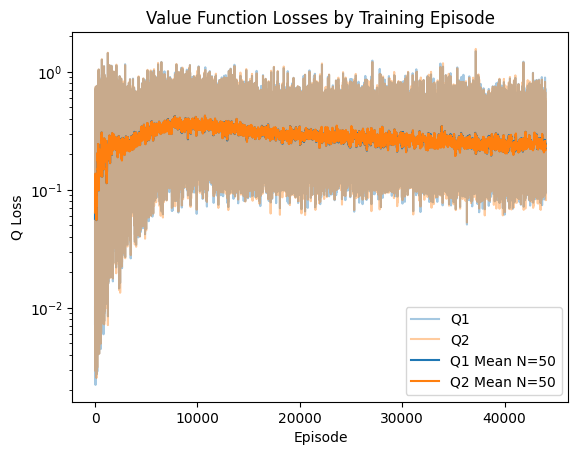

In [20]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

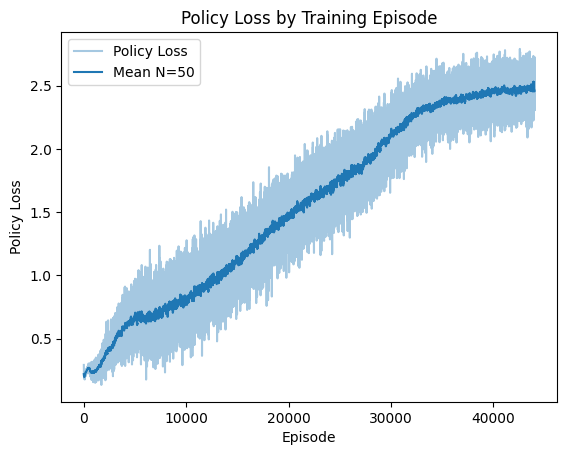

In [21]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

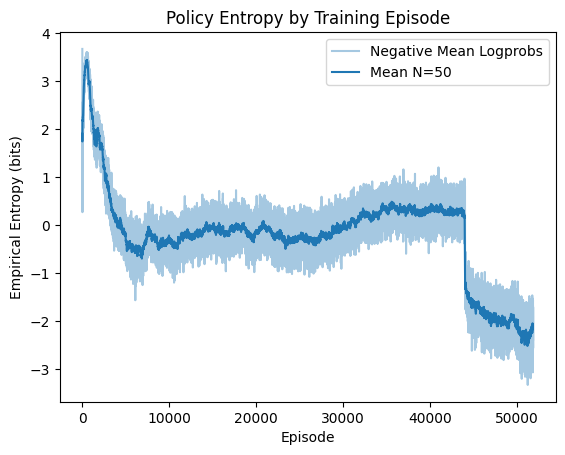

In [45]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

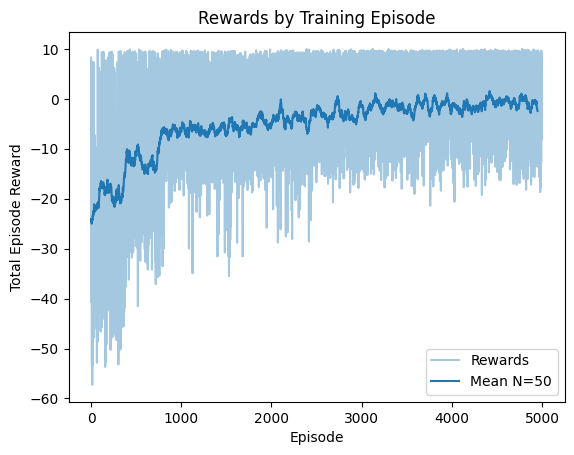

In [23]:
plot_rewards(trainer.logs["Rewards"], "./results")

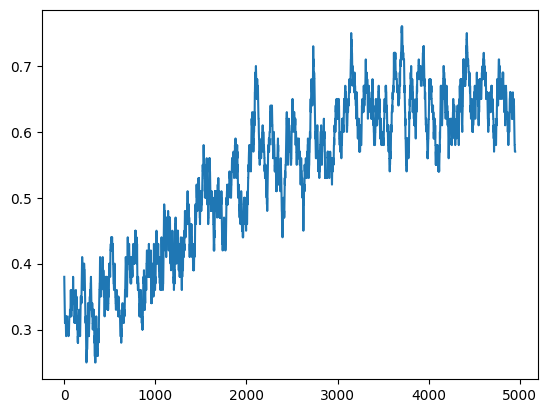

In [26]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

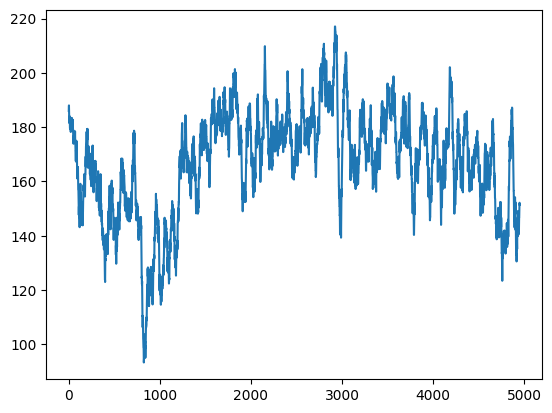

In [27]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

In [ ]:
trainer.evaluate(opponent, 10, render=True)

([9.58605120584371,
  9.55736888111625,
  -11.431473124672667,
  9.539714189271045,
  -3.44601041668548,
  9.724531691396177,
  6.138460734562132,
  -11.664755510801442,
  -7.407107651639524,
  -12.117607727895628],
 [1, 1, -1, 1, 0, 1, 1, -1, 0, -1])

In [34]:
trainer.reset()

In [31]:
rewards, scores = trainer.evaluate(opponent, 1000, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(-0.3387637884433925), np.float64(0.6765))

In [32]:
rewards, scores = trainer.evaluate(h_env.BasicOpponent(), 1000, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(-1.9451479265371412), np.float64(0.5555))

In [35]:
trainer.agent.alpha = 0.005

In [41]:
trainer.train(h_env.BasicOpponent(weak=False), new_episodes, train_interval, log_interval, max_timesteps)

  5520: Reward:   -0.572 Winrate:    0.650
  5540: Reward:   -0.709 Winrate:    0.650
  5560: Reward:   -1.097 Winrate:    0.675
  5580: Reward:    2.521 Winrate:    0.800
  5600: Reward:    3.677 Winrate:    0.850
  5620: Reward:    3.045 Winrate:    0.850
  5640: Reward:   -0.367 Winrate:    0.700
  5660: Reward:   -2.114 Winrate:    0.675
  5680: Reward:   -0.958 Winrate:    0.700
  5700: Reward:    1.050 Winrate:    0.700
  5720: Reward:    2.317 Winrate:    0.775
  5740: Reward:    0.080 Winrate:    0.675
  5760: Reward:    1.070 Winrate:    0.775
  5780: Reward:    0.336 Winrate:    0.725
  5800: Reward:   -0.273 Winrate:    0.725
  5820: Reward:    2.413 Winrate:    0.800
  5840: Reward:    0.281 Winrate:    0.675
  5860: Reward:   -2.032 Winrate:    0.650
  5880: Reward:   -0.732 Winrate:    0.650
  5900: Reward:   -0.604 Winrate:    0.650
  5920: Reward:    1.556 Winrate:    0.750
  5940: Reward:   -1.915 Winrate:    0.600
  5960: Reward:    1.149 Winrate:    0.700
  5980: Rew

In [83]:

rewards, scores = trainer.evaluate(h_env.BasicOpponent(), 1000, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(2.3724176317657846), np.float64(0.748))

In [84]:

rewards, scores = trainer.evaluate(h_env.BasicOpponent(weak=False), 1000, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(0.45456719251832284), np.float64(0.7125))

In [86]:

rewards, scores = trainer.evaluate(agent1, 1000, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(-1.4720594948916483), np.float64(0.656))

In [87]:
rewards, scores = trainer.evaluate(agent2, 1000, render=False)
np.mean(rewards), 0.5 * (np.mean(scores)+1)

(np.float64(-5.814260893761039), np.float64(0.5445))

In [85]:
trainer.save_agent(filepath)

In [77]:
trainer.evaluate(agent2, 10, render=True)

([-6.911350327444768,
  -8.061802963526182,
  -7.059706729573185,
  -9.705663850971792,
  -6.145945935759374,
  -8.741525961490764,
  -6.819266210018157,
  -8.260685816569161,
  -7.006201367320402,
  -7.241915678785684],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [81]:
trainer.reset()

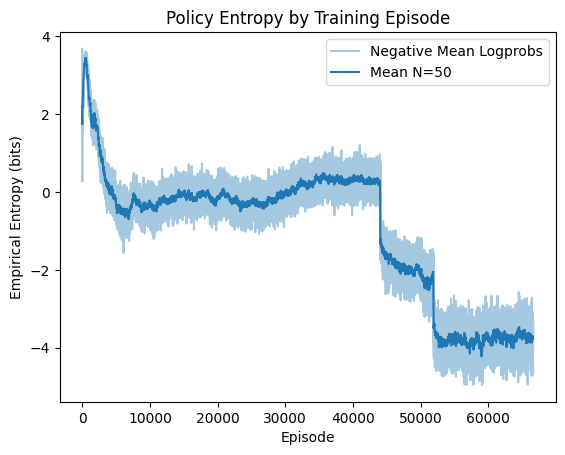

In [88]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

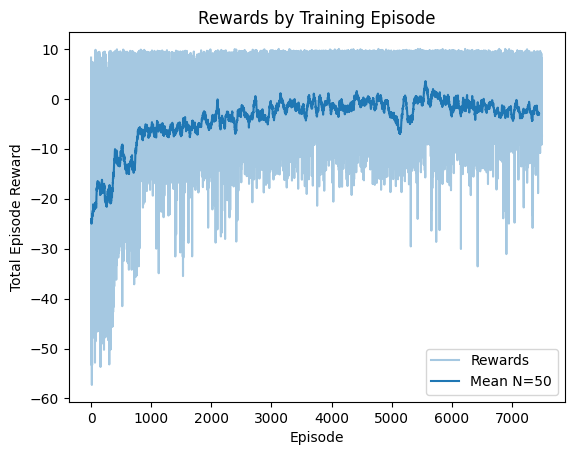

In [89]:
plot_rewards(trainer.logs["Rewards"], "./results")

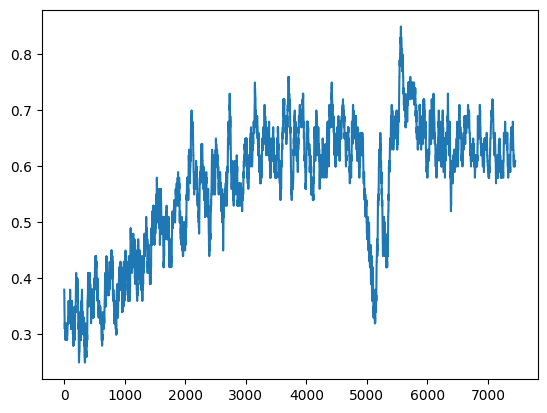

In [90]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

In [52]:
trainer.agent.alpha = 0.003

In [62]:
SCALING = np.asarray([ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4.0 ,4.0])
ACTION_BOUNDS = (-np.ones(4), np.ones(4))

agent1 = from_dict(trainer.env, action_bounds=ACTION_BOUNDS, obs_scale=SCALING, **params)
state = torch.load(f"{filepath}-4000.pth")
agent1.restore_state(state)

agent2 = from_dict(trainer.env, action_bounds=ACTION_BOUNDS, obs_scale=SCALING, **params)
state = torch.load(f"{filepath}-6000.pth")
agent2.restore_state(state)

In [82]:
agents = [trainer.agent, h_env.BasicOpponent(), agent1, h_env.BasicOpponent(weak=False), agent2]
for i in range(50):
    trainer.train(agents[i % 5], 10, train_interval, 10, max_timesteps)

  7010: Reward:   -5.460 Winrate:    0.550
  7020: Reward:   -0.000 Winrate:    0.650
  7030: Reward:   -2.806 Winrate:    0.650
  7040: Reward:   -1.272 Winrate:    0.650
  7050: Reward:   -8.481 Winrate:    0.500
  7060: Reward:   -6.937 Winrate:    0.500
  7070: Reward:   -0.960 Winrate:    0.650
  7080: Reward:    0.897 Winrate:    0.750
  7090: Reward:    4.396 Winrate:    0.850
  7100: Reward:   -4.166 Winrate:    0.650
  7110: Reward:   -5.400 Winrate:    0.550
  7120: Reward:    2.397 Winrate:    0.750
  7130: Reward:   -2.359 Winrate:    0.650
  7140: Reward:   -0.569 Winrate:    0.700
  7150: Reward:   -3.399 Winrate:    0.600
  7160: Reward:   -6.591 Winrate:    0.500
  7170: Reward:    2.041 Winrate:    0.750
  7180: Reward:   -7.074 Winrate:    0.450
  7190: Reward:   -1.575 Winrate:    0.650
  7200: Reward:   -3.633 Winrate:    0.700
  7210: Reward:   -6.944 Winrate:    0.450
  7220: Reward:    0.431 Winrate:    0.700
  7230: Reward:   -0.734 Winrate:    0.700
  7240: Rew